# Assignment 3
### Due 9/23. Do four of five.

1. 
- Open the NHANES (or Ames prices or college completion datasets, if you prefer)
- Find two categorical variables of interest (there are 198, and short descriptions are given in the `nhanes_meta_17_18.csv` file). Investigate their missing values (you don't have to focus on missing values for this analysis like we did with police use of force, but always be aware of how dirty the data are)
- Compute a contingency table for your categorical $X$ and $Y$
- Discuss any interesting patterns (or lack of one) that you observe

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
data = pd.read_csv('data/nhanes_data_17_18.csv')
data.head()

C:\Users\wanns\AppData\Local\Temp\ipykernel_28356\2577285520.py:1: DtypeWarning: Columns (142) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('data/nhanes_data_17_18.csv')


,SEQN,GeneralHealthCondition,EverBreastfedOrFedBreastmilk,AgeStoppedBreastfeedingdays,AgeFirstFedFormuladays,AgeStoppedReceivingFormuladays,AgeStartedOtherFoodbeverage,AgeFirstFedMilkdays,TypeOfMilkFirstFedWholeMilk,TypeOfMilkFirstFed2Milk,...,DaysSmokedCigsDuringPast30Days,AvgCigarettesdayDuringPast30Days,TriedToQuitSmoking,TimesStoppedSmokingCigarettes,HowLongWereYouAbleToStopSmoking,UnitOfMeasureDayweekmonthyear_2_SMQ,CurrentSelfreportedHeightInches,CurrentSelfreportedWeightPounds,TriedToLoseWeightInPastYear,TimesLost10LbsOrMoreToLoseWeight
0,93703.0,NaN,1.0,273.0,1.0,365.0,152.0,365.0,Whole or regular milk,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,93704.0,NaN,1.0,60.0,3.0,365.0,126.0,365.0,Whole or regular milk,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,93705.0,Good,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,63.0,165.0,0.0,11 times or more
3,93706.0,Very good,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,68.0,145.0,0.0,Never
4,93707.0,Good,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
print(data[['GeneralHealthCondition', 'CoveredByHealthInsurance']].isna().sum(), data.shape)

GeneralHealthCondition      2402
CoveredByHealthInsurance      20
dtype: int64 (8366, 198)


CoveredByHealthInsurance doesn't have many missing values considering only 20 are na and there are 8366 observations in our dataset. However, GeneralHealthCondition has a significant amount of missing values, 2402 out of the 8366 are na, which is a a little under a third. We can safely say there probably is no concern for the missing values in CoveredByHealthInsurance but for GeneralHealthCondition we should keep in mind that there is potential to be a pattern for missingness with large quantity of nas, so we use the nas for GeneralHealthCondition in the contingency table below.

In [4]:
data['GeneralHealthConditionNA'] = data['GeneralHealthCondition'].isna()
pd.crosstab(data['GeneralHealthConditionNA'], data['CoveredByHealthInsurance'], normalize='columns')

CoveredByHealthInsurance,0.0,1.0
GeneralHealthConditionNA,,
False,0.835176,0.696096
True,0.164824,0.303904


We notice a pattern that significantly more GeneralHealthCondition statuses are missing for people covered by health insurance compared to those not covered by health insurance. This is a little interesting because I would expect those not covered by health insurance to have less data on them.

2. 
- Open the NHANES dataset
- Find a categorical and numeric variable of interest (there are 198, and short descriptions are given in the `nhanes_meta_17_18.csv` file). Investigate their missing values (you don't have to focus on missing values for this analysis, but always be aware of them)
- Make descriptive tables and grouped kernel density plots to represent the variation in your numeric $Y$ conditional on your categorical $X$
- Discuss any interesting patterns (or lack of one) that you observe

In [5]:
print(data[['GeneralHealthCondition', 'CigarettesSmokedPerDay']].isna().sum())

GeneralHealthCondition    2402
CigarettesSmokedPerDay    7450
dtype: int64


We see a very large amount of CigarettesSmokedPerDay entries are missing, out of 8366 observations only a little under a thousand have entries, the rest are na. A significant amount of GeneralHealthCondition entries are also missing, a little under a third out of the 8366. With such a large amount missing for CigarettesSmokedPerDay I either think personally maybe they counted refusal to answer as NA or something similar.

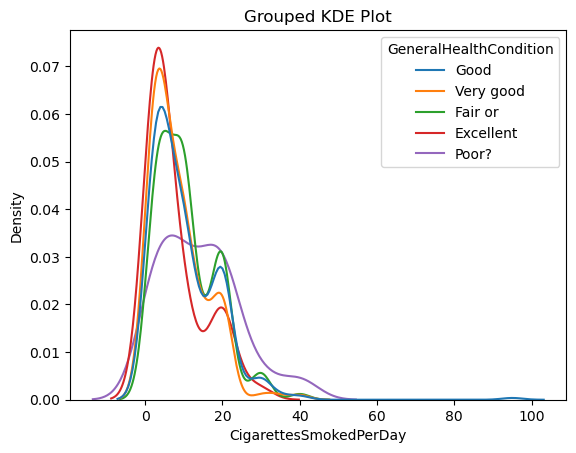

CigarettesSmokedPerDay                             \
                                        count       mean        std  min   
GeneralHealthCondition                                                     
Excellent                                57.0   7.701754   7.314284  1.0   
Fair or                                 263.0  10.695817   7.639708  1.0   
Good                                    396.0  10.207071   8.961100  1.0   
Poor?                                    40.0  13.950000  10.122202  1.0   
Very good                               160.0   8.556250   7.089497  1.0   

                                                
                         25%   50%   75%   max  
GeneralHealthCondition                          
Excellent               3.00   4.0  10.0  30.0  
Fair or                 5.00  10.0  15.5  40.0  
Good                    4.00   8.0  15.0  95.0  
Poor?                   5.75  12.5  20.0  40.0  
Very good               3.00   6.0  12.0  40.0

In [6]:
conditioner = 'GeneralHealthCondition'
sns.kdeplot(data=data, x='CigarettesSmokedPerDay', hue=conditioner, common_norm=False).set(title='Grouped KDE Plot')
plt.show()
data.loc[:,['CigarettesSmokedPerDay', conditioner]].groupby(conditioner).describe()

One thing we see from the grouped KDE plot is that people with varying general health conditions actually don't have a huge difference in whether they smoked cigarettes or not. However, the quantity of cigarettes did differ across groups, those with fair to excellent health are highly concentrated around the 0-10 cigarettes a day interval with some smoking higher. Meanwhile those clasified as poor general health were split more evently below and above the 10 cigarette a day line, (meaning within their group more of them smoked more cigarettes compared to other groups). Generally speaking though besides this the distributions between all 5 groups have a lot of overlap.

From the descriptive table we see the same pattern reflected, the min is 1 cigarette smoked a day for all health condition categories, and poor health condition group has the highest mean cigarettes smoked a day and also the most spread (highest standard deviation). It also sheds light on the other quantiles more than the KDE, we see that as we progress to poorer health condition groups the median number of cigarettes smoked a day increases, which makes sense.

4. 
- Write a class or set of functions that implement the LCLS/Naradaya-Watson estimator, using the Silverman plug-in estimate for the conditioning variable $X$ as the bandwidth.
- From one of the course data sets, find two numeric variables of interest, analyze their relationship with the the LCLS/Naradaya-Watson estimator, and discuss your results.

Using Silverman rule of thumb, h=3.981


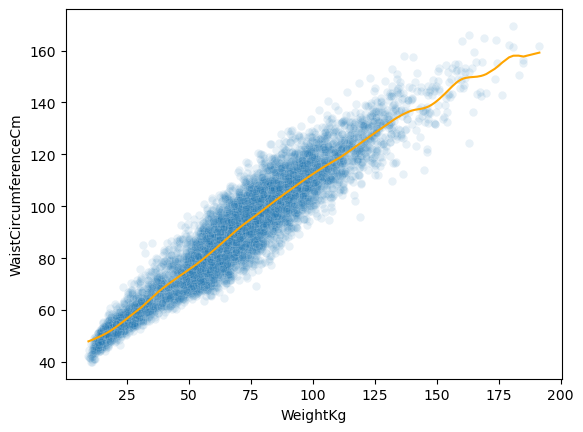

In [7]:
def LCLS(x,y,h=None,plot=True): # LCLS estimator
    # handle nas
    mask = ~(x.isna() | y.isna())
    x = x[mask]
    y = y[mask]

    n=len(x)
    grid=np.sort(np.unique(x))

    if h is None:
        iqr = np.quantile(x, 0.75) - np.quantile(x, 0.25)
        h = 0.9 * min(np.std(x), (np.percentile(x,75)-np.percentile(x,25))/1.34) * n**(-1/5) # Silverman plug-in estimate
        print(f'Using Silverman rule of thumb, h={h:.3f}')

    I = -(x.to_numpy().reshape(-1,1) - grid.reshape(1,-1))**2
    K = np.exp(I/(2*h**2)) / (np.sqrt(2*np.pi)*h) # 

    numerator = y@K
    denominator = np.sum(K, axis=0)
    yhat = numerator/denominator

    if plot:
        sns.scatterplot(x=x, y=y, alpha=0.1)
        sns.lineplot(x=grid, y=yhat, color='orange')

    return grid, yhat

grid, yhat = LCLS(data['WeightKg'], data['WaistCircumferenceCm'])

We see that there appears to be a positive correlation between waist circumference and weight, which makes sense. As one variable increases, the other tends to increase as well. We see a general linear trend of the data distribution estimated by the LCLS line plot, which holds out until around 135 kg on the weight axis. Afterwards the estimation line becomes non-linear due to there not being a lot of data points in that area.

5. 
- In any of the available data sets, investigate the relationships between pairs of variables $(X,Y)$ with a scatterplot and CEF (for example, price on area)
- Is this relationship plausibly causal, or are there missing variables that might explain at least part of the relationship between your variables? These can be "conceptual" rather than "practical"; for example, 'talent' or 'grit' probably explain education outcomes, but are almost impossible to measure. We are asking whether there are hypothetical **threats to causal identification** of the effect of $X$ on $Y$.
- Explain how, regardless of the threat to causal identification, you can still use your model to predict $Y$ given $X$, as long as you don't intervene in the system to control the outcome

C:\Users\wanns\AppData\Local\Temp\ipykernel_28356\421929682.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = data[['GeneralHealthCondition', '60SecPulse30SecPulse2']].groupby('GeneralHealthCondition').mean().reset_index()


<Axes: xlabel='GeneralHealthCondition', ylabel='60SecPulse30SecPulse2'>

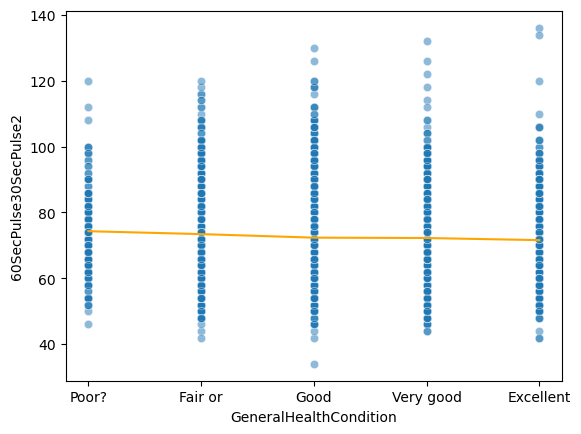

In [15]:
data['GeneralHealthCondition'] = pd.Categorical(data['GeneralHealthCondition'], 
                                     categories=['Poor?', 'Fair or', 'Good', 'Very good', 'Excellent'], 
                                     ordered=True)
means = data[['GeneralHealthCondition', '60SecPulse30SecPulse2']].groupby('GeneralHealthCondition').mean().reset_index()
sns.scatterplot(x=data['GeneralHealthCondition'], y=data['60SecPulse30SecPulse2'], alpha=0.5)
sns.lineplot(data=means, x='GeneralHealthCondition', y='60SecPulse30SecPulse2', color='orange')

After looking at the scatterplot, there does not seem to be any particular relationship between health condition and pulse rate. I had expected poorer health individuals to have different pulse rates but it does not appear to be the case, all categories of health seem to have similar pulse rates, denoted by the almost horizontal CEF line.

Since there is no apparent relationship, there is no plausibility to consider. But something that could explain there being no relationship when one is expected is that perhaps just that pulse rate and heart rate are not entirely the same, so if you expect heart rate to be slightly different, it might not be reflected in the pulse rate.

C:\Users\wanns\AppData\Local\Temp\ipykernel_28356\1261387068.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = data[['GeneralHealthCondition', 'AnnualHouseholdIncome']].groupby('GeneralHealthCondition').mean().reset_index()


<Axes: xlabel='GeneralHealthCondition', ylabel='AnnualHouseholdIncome'>

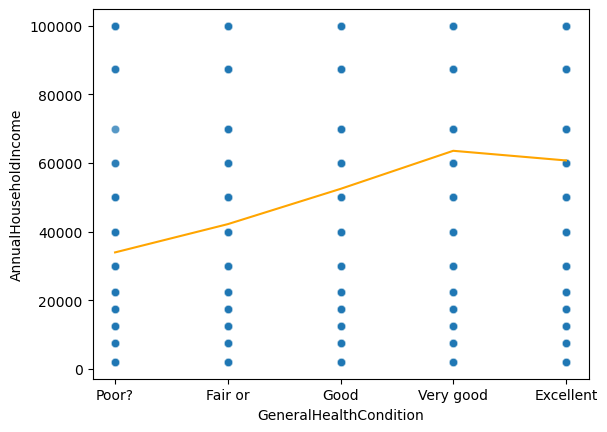

In [16]:
means = data[['GeneralHealthCondition', 'AnnualHouseholdIncome']].groupby('GeneralHealthCondition').mean().reset_index()
sns.scatterplot(x=data['GeneralHealthCondition'], y=data['AnnualHouseholdIncome'], alpha=0.5)
sns.lineplot(data=means, x='GeneralHealthCondition', y='AnnualHouseholdIncome', color='orange')

After looking at the scatterplot, there does appear to be a relationship between GeneralHealthCondition and AnnualHouseholdIncome. Those with better health conditions tend to have higher annual household income, which makes sense because those without money may not have access to the resources or the same opportunity to take care of their health. This is supported by the CEF line that we see has a mostly positive slope.

This relationship is plausibly causal and might not just be correlation, for the reasons mentioned above. Those with higher income probably have better access to resources to take care of their health more effectively and more often. Other variables that could explain this relationship is living conditions, if you live in the middle of nowhere you probably have less access to healthcare compared to a big city. This is somewhat related to income though as you would have to be making more to live in a city compared to in the middle of nowhere.

However even if there cannot be a true causal relationship established, it remains a fact that the variables are seemingly correlated, which is all the model needs to make predictions. As long as we don't do anything that could negatively affect prediction (intervene) with the model, we can safely use it to estimate a response based on the predictor it is correlated with.